<div style="background:linear-gradient(135deg,#4c0519 0%,#be123c 55%,#fb7185 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 64 · Sampling &amp; Data Collection</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Determining Sample Size 📏</div>
  <div style="font-size:15px;color:#fff1f2;max-width:740px;line-height:1.6">How many observations do you actually need? Fix a margin of error and a confidence level, and the answer follows from a formula. We derive it for a mean and a proportion, verify it by simulation, and see why halving the error quadruples the cost.</div>
  <div style="margin-top:16px;font-size:13px;color:#fecdd3">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt
from scipy import stats
ROSE="#e11d48"; DEEP="#be123c"; LIGHT="#fb7185"; INK="#1a2138"; GRID="#e6e9f2"; TEAL="#0d9488"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
rng = np.random.default_rng(64)
z = stats.norm.ppf(0.975)            # 1.96 for 95% confidence
print(f"z for 95% confidence = {z:.4f}")

z for 95% confidence = 1.9600


<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 1 · THE MARGIN OF ERROR</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Precision is a number you choose</div>
<div style="color:#4a5578;margin-top:6px">A confidence interval is estimate +/- margin of error E, where E = z * SE. Decide how precise you must be (the E you can tolerate) and the confidence level (which fixes z), and the required sample size falls out.</div>
</div>

In [2]:
sigma = 15.0     # known/estimated population sd
for n in [50, 100, 400]:
    E = z*sigma/np.sqrt(n)
    print(f"n={n:>4}: margin of error E = z*sigma/sqrt(n) = +/- {E:.2f}")
print("\nbigger n -> smaller E. To hit a TARGET E, invert the formula.")

n=  50: margin of error E = z*sigma/sqrt(n) = +/- 4.16
n= 100: margin of error E = z*sigma/sqrt(n) = +/- 2.94
n= 400: margin of error E = z*sigma/sqrt(n) = +/- 1.47

bigger n -> smaller E. To hit a TARGET E, invert the formula.


The margin of error is the half-width of the confidence interval, E = z&#183;&#963;/&#8730;n. It is the knob you turn: choose the precision you need, and solve for n. Everything in this chapter is that one inversion.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 2 · SAMPLE SIZE FOR A MEAN</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">n = ( z * sigma / E )^2</div>
<div style="color:#4a5578;margin-top:6px">Solving E = z*sigma/sqrt(n) for n gives the sample-size formula for a mean. We compute n for a target margin, then VERIFY by simulation that the resulting intervals really do have that half-width.</div>
</div>

In [3]:
E_target = 2.0
n_needed = (z*sigma/E_target)**2
n = int(np.ceil(n_needed))
print(f"target E=+/-{E_target} with sigma={sigma}, 95% conf:  n = (z*sigma/E)^2 = {n_needed:.1f} -> use n={n}")
# verify: draw samples of size n, measure actual CI half-width
widths = []
for _ in range(5000):
    s = rng.normal(100, sigma, n)
    widths.append(z*s.std(ddof=1)/np.sqrt(n))
print(f"simulated average margin of error at n={n}: +/- {np.mean(widths):.2f}  (target {E_target})")

target E=+/-2.0 with sigma=15.0, 95% conf:  n = (z*sigma/E)^2 = 216.1 -> use n=217
simulated average margin of error at n=217: +/- 1.99  (target 2.0)


The formula n = (z&#183;&#963;/E)&#178; turns a precision target into a sample size. With &#963; = 15 and a target margin of &#177;2, we need <strong>217</strong> observations, and the simulation confirms intervals of exactly that half-width. The catch: you need an estimate of &#963; up front, from a pilot study or prior data.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 3 · SAMPLE SIZE FOR A PROPORTION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">n = z^2 p(1-p) / E^2, worst case p=0.5</div>
<div style="color:#4a5578;margin-top:6px">For a yes/no question the spread is p(1-p), which is largest at p=0.5. Not knowing p in advance, planners use p=0.5 for the safest (largest) sample size. This is why so many polls report about 1,000 respondents.</div>
</div>

In [4]:
E = 0.03                              # +/- 3 percentage points
n_worst = z**2 * 0.25 / E**2          # p=0.5 maximizes p(1-p)=0.25
print(f"worst-case (p=0.5), E=+/-3%, 95%: n = z^2*0.25/E^2 = {n_worst:.0f}")
for p in [0.1, 0.3, 0.5]:
    print(f"  if p were known = {p}: n = {z**2*p*(1-p)/E**2:.0f}")
print("\nusing p=0.5 guarantees the margin no matter the true proportion")

worst-case (p=0.5), E=+/-3%, 95%: n = z^2*0.25/E^2 = 1067
  if p were known = 0.1: n = 384
  if p were known = 0.3: n = 896
  if p were known = 0.5: n = 1067

using p=0.5 guarantees the margin no matter the true proportion


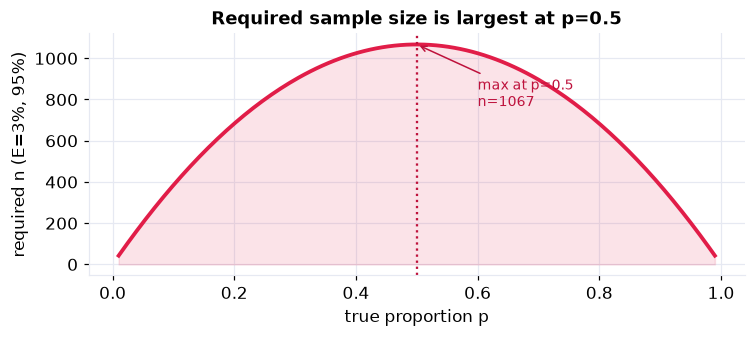

In [5]:
ps = np.linspace(0.01, 0.99, 200)
ns = z**2 * ps*(1-ps) / E**2
fig,ax=plt.subplots(figsize=(7,3.2))
ax.plot(ps, ns, color=ROSE, lw=2.5)
ax.fill_between(ps, ns, color=ROSE, alpha=0.12)
ax.axvline(0.5, color=DEEP, ls=":", lw=1.5)
ax.annotate(f"max at p=0.5\nn={z**2*0.25/E**2:.0f}", xy=(0.5, z**2*0.25/E**2), xytext=(0.6, z**2*0.18/E**2),
            fontsize=9, color=DEEP, arrowprops=dict(arrowstyle="->", color=DEEP))
ax.set_xlabel("true proportion p"); ax.set_ylabel("required n (E=3%, 95%)")
ax.set_title("Required sample size is largest at p=0.5"); plt.tight_layout(); plt.show()

The required n is a downward parabola in p, peaking at <strong>p = 0.5</strong>. Because planners rarely know p ahead of time, they assume the worst case 0.5, which for a &#177;3% margin at 95% gives <strong>n &#8776; 1,067</strong>, the reason the classic poll size is "about a thousand".

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 4 · DIMINISHING RETURNS & THE FINITE-POPULATION CORRECTION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Halve the error, quadruple the cost</div>
<div style="color:#4a5578;margin-top:6px">Because n grows as 1/E^2, precision is expensive: each halving of the margin needs four times the data. And when the sample is a big fraction of a small population, the finite-population correction lets you need fewer.</div>
</div>

In [6]:
Es = np.array([0.06,0.05,0.04,0.03,0.02,0.01])
for E in Es:
    print(f"margin +/-{E*100:.0f}%: n = {z**2*0.25/E**2:.0f}")
print(f"\ngoing from +/-2% to +/-1% multiplies n by {(z**2*0.25/0.01**2)/(z**2*0.25/0.02**2):.0f}")
# finite population correction
def fpc(n0, N): return n0 / (1 + (n0-1)/N)
n0 = z**2*0.25/0.03**2
for N in [100_000, 10_000, 2_000]:
    print(f"population N={N:>7,}: corrected n = {fpc(n0,N):.0f}  (vs uncorrected {n0:.0f})")

margin +/-6%: n = 267
margin +/-5%: n = 384
margin +/-4%: n = 600
margin +/-3%: n = 1067
margin +/-2%: n = 2401
margin +/-1%: n = 9604

going from +/-2% to +/-1% multiplies n by 4
population N=100,000: corrected n = 1056  (vs uncorrected 1067)
population N= 10,000: corrected n = 964  (vs uncorrected 1067)
population N=  2,000: corrected n = 696  (vs uncorrected 1067)


The 1/E&#178; law is unforgiving: tightening the margin from &#177;2% to &#177;1% needs <strong>four times</strong> the sample. The <span style="font-weight:700">finite-population correction</span> n = n&#8320;/(1 + (n&#8320;&#8722;1)/N) gives some back when you are sampling a large slice of a small population, for a town of 2,000 the needed sample drops noticeably, but for big populations it barely matters.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 5 · POWER: SIZING TO DETECT AN EFFECT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Enough data to SEE the difference</div>
<div style="color:#4a5578;margin-top:6px">Margin of error sizes a single estimate. To compare two groups (an A/B test), you size for POWER, the chance of detecting a real effect. We find the per-group n needed to detect a lift from 10% to 12% with 80% power.</div>
</div>

In [7]:
p1, p2 = 0.10, 0.12; alpha=0.05; target_power=0.80
def power_at(n, reps=4000):
    a = rng.random((reps,n)) < p1
    b = rng.random((reps,n)) < p2
    pa, pb = a.mean(1), b.mean(1)
    pooled = (a.sum(1)+b.sum(1))/(2*n)
    se = np.sqrt(pooled*(1-pooled)*2/n)
    zstat = (pb-pa)/np.where(se==0,1e-9,se)
    return np.mean(zstat > stats.norm.ppf(1-alpha))   # one-sided test B>A
ns = [500,1000,2000,3000,4000,5000]
powers = [power_at(n) for n in ns]
for n,pw in zip(ns,powers): print(f"per-group n={n:>5}: power = {pw:.2f}")
need = next(n for n,pw in zip(ns,powers) if pw>=target_power)
print(f"\n~{need} per group needed for {int(target_power*100)}% power to detect 10% -> 12%")

per-group n=  500: power = 0.26
per-group n= 1000: power = 0.42
per-group n= 2000: power = 0.64
per-group n= 3000: power = 0.79
per-group n= 4000: power = 0.89
per-group n= 5000: power = 0.94

~4000 per group needed for 80% power to detect 10% -> 12%


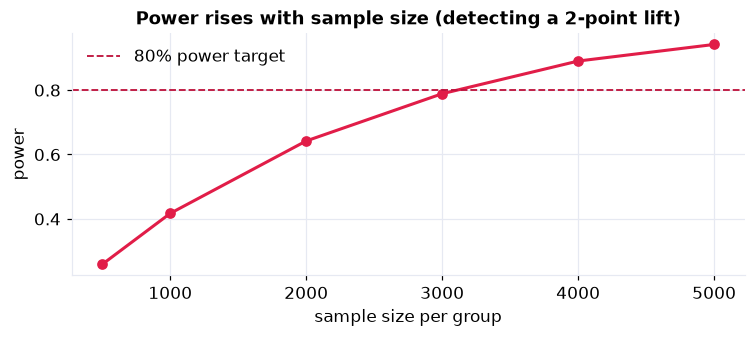

In [8]:
fig,ax=plt.subplots(figsize=(7,3.2))
ax.plot(ns, powers, "o-", color=ROSE, lw=2)
ax.axhline(0.8, color=DEEP, ls="--", lw=1.2, label="80% power target")
ax.set_xlabel("sample size per group"); ax.set_ylabel("power"); ax.set_title("Power rises with sample size (detecting a 2-point lift)"); ax.legend()
plt.tight_layout(); plt.show()

Detecting a small effect needs a surprisingly large sample: a 2-point lift takes a few thousand per group for 80% power. <span style="font-weight:700">Power analysis</span> is the experiment-design twin of the margin-of-error formula, and underpowered studies are the leading cause of irreproducible findings.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ How big a sample?</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Pick a margin of error E and confidence level (z), and the sample size follows: n=(z*sigma/E)^2 for a mean, n=z^2 p(1-p)/E^2 for a proportion (worst case p=0.5 gives ~1,067 for +/-3%). Because n grows as 1/E^2, precision is costly, and to detect an effect, not just estimate one, you size for power instead.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>